In [3]:
import pandas as pd
import numpy as np
import shap
import pickle

In [4]:
X = pd.read_csv("../data/feature_store/final_features.csv")

print("Shape:", X.shape)
X.head()

Shape: (1782, 73)


,toss_winner_is_team1,team1_Delhi Capitals,team1_Gujarat Titans,team1_Kolkata Knight Riders,team1_Lucknow Super Giants,team1_Mumbai Indians,team1_Punjab Kings,team1_Rajasthan Royals,team1_Royal Challengers Bangalore,team1_Sunrisers Hyderabad,...,venue_Shaheed Veer Narayan Singh International Stadium,venue_Sharjah Cricket Stadium,venue_Sheikh Zayed Stadium,venue_St George's Park,venue_Subrata Roy Sahara Stadium,venue_SuperSport Park,venue_Wankhede Stadium,"venue_Wankhede Stadium, Mumbai","venue_Zayed Cricket Stadium, Abu Dhabi",toss_decision_field
0,1,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,1,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
2,0,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
with open("../models/best_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully")

Model loaded successfully


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

# Fix for classification (very important)
shap_values = shap_values[1]

print("SHAP values computed")

SHAP values computed


In [7]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)


if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_values = shap_values[:, :, 1]

print("Fixed SHAP shape:", np.array(shap_values).shape)
print("X shape:", X.shape)

Fixed SHAP shape: (1782, 73)
X shape: (1782, 73)


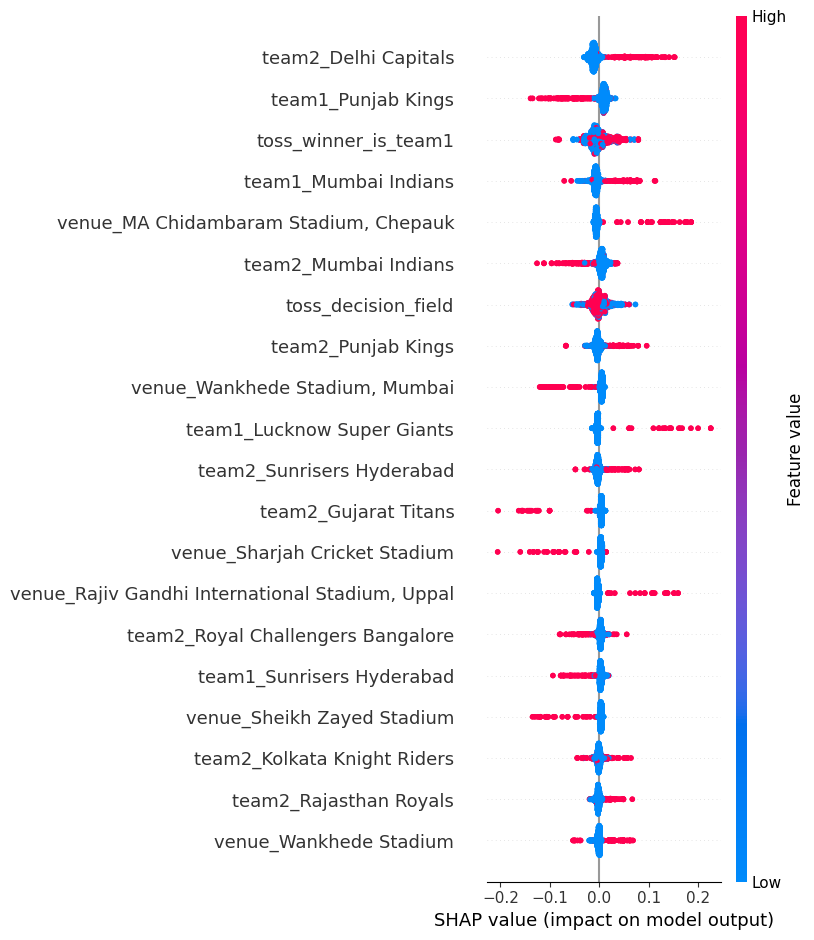

In [8]:
shap.summary_plot(shap_values, X)

In [9]:
shap.initjs()

In [10]:
sample_index = 10

shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample_index],
    X.iloc[sample_index]
)

In [11]:
sample = X.iloc[10]
values = shap_values[10]

print("Feature Contributions:\n")

for i, feature in enumerate(X.columns):
    print(f"{feature}: {values[i]:.4f}")

Feature Contributions:

toss_winner_is_team1: -0.0292
team1_Delhi Capitals: 0.0001
team1_Gujarat Titans: -0.0015
team1_Kolkata Knight Riders: 0.0001
team1_Lucknow Super Giants: -0.0053
team1_Mumbai Indians: -0.0066
team1_Punjab Kings: 0.0070
team1_Rajasthan Royals: 0.0008
team1_Royal Challengers Bangalore: -0.0148
team1_Sunrisers Hyderabad: 0.0017
team2_Delhi Capitals: -0.0190
team2_Gujarat Titans: 0.0033
team2_Kolkata Knight Riders: -0.0152
team2_Lucknow Super Giants: -0.0004
team2_Mumbai Indians: -0.1119
team2_Punjab Kings: -0.0058
team2_Rajasthan Royals: -0.0069
team2_Royal Challengers Bangalore: -0.0045
team2_Sunrisers Hyderabad: -0.0073
venue_Arun Jaitley Stadium, Delhi: 0.0001
venue_Barabati Stadium: -0.0006
venue_Barsapara Cricket Stadium, Guwahati: -0.0002
venue_Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow: 0.0000
venue_Brabourne Stadium: -0.0012
venue_Brabourne Stadium, Mumbai: 0.0004
venue_Buffalo Park: 0.0002
venue_De Beers Diamond Oval: -0.0000
venu

In [12]:
positive = []
negative = []

for i, val in enumerate(values):
    if val > 0:
        positive.append((X.columns[i], val))
    else:
        negative.append((X.columns[i], val))

print("\nPositive Factors (favoring Team1 win):")
for f, v in sorted(positive, key=lambda x: -x[1])[:5]:
    print(f"{f}: {v:.4f}")

print("\nNegative Factors (against Team1 win):")
for f, v in sorted(negative, key=lambda x: x[1])[:5]:
    print(f"{f}: {v:.4f}")


Positive Factors (favoring Team1 win):
venue_MA Chidambaram Stadium, Chepauk: 0.0360
toss_decision_field: 0.0163
team1_Punjab Kings: 0.0070
venue_Sharjah Cricket Stadium: 0.0035
team2_Gujarat Titans: 0.0033

Negative Factors (against Team1 win):
team2_Mumbai Indians: -0.1119
toss_winner_is_team1: -0.0292
team2_Delhi Capitals: -0.0190
team2_Kolkata Knight Riders: -0.0152
team1_Royal Challengers Bangalore: -0.0148
